# KX BPIPE for Bloomberg Data Accelerator API Examples

This notebook demonstrates calling the `getTicks()` & `getStats()` Library API via REST for the KX BPIPE for Bloomberg Data Accelerator. To use this, you will need a running instance of kdb Insights Enterprise with the BPIPE accelerator deployed.

> Service account credentials are required to authorize requests. More detail on creating them is available on our page about [managing service accounts](https://code.kx.com/insights/enterprise/security/managing-service-accounts.html), or speak with your kdb Insights Enterprise administrator.

kdb Accelerators are packages for kdb products that address typical industry use cases. Using an Accelerator allows you to leapfrog the first phases of a project or Insights implementation, skipping common boilerplate or initial effort and jumping straight to value adding work. They are a customization-first approach to developing on kdb products, helping you learn and unlock the value of KX products faster.

You can read more about the BPIPE Accelerator in the [KX BPIPE for Bloomberg Data Accelerator](https://code.kx.com/insights/accelerators/fsi/).


---

### Imports, Constants, Helper Function, & Authentication

> `Tip:` run pip install -r requirements.txt


In [1]:
import os
import requests
import json
import numpy as np
import pandas as pd
from requests_oauth2client import OAuth2Client, OAuth2ClientCredentialsAuth
from getpass import getpass
from datetime import datetime, timedelta
import plotly.graph_objects as go
import plotly.io as pio

You should edit the constants below to reflect your particular kdb Insights instance details. You will be prompted for a Client and Secret.


In [ ]:
# Constants - set these as appropriate
INSIGHTS_HOST   = '<HOST>' # Your Insights Enterprise hostname
INSIGHTS_REALM  = '<REALM>' # Your Insights realm, typically 'insights'
INSIGHTS_CLIENT = input("kdb Insights client: ")           # Your insights client (service account name)
INSIGHTS_SECRET = getpass("kdb Insights client secret: ")  # Your insights secret

In [3]:
# Authentication
oauth2client = OAuth2Client(
    token_endpoint='https://' + INSIGHTS_HOST + '/realms/' + INSIGHTS_REALM + '/protocol/openid-connect/token',
    auth=(INSIGHTS_CLIENT, INSIGHTS_SECRET))
oauth2cc = OAuth2ClientCredentialsAuth(oauth2client, scope='roles')

### Set your start and end query time


In [4]:
# Get the current time as endTS
endTS_raw = datetime.now()

# Floor startTS to the previous full hour
startTS_raw = (endTS_raw - timedelta(hours=1)).replace(minute=0, second=0, microsecond=0)

# Format the timestamps with 9 decimal places in microseconds
startTS = startTS_raw.strftime("%Y.%m.%dD%H:%M:%S.") + f"{startTS_raw.microsecond:09d}"
endTS = endTS_raw.strftime("%Y.%m.%dD%H:%M:%S.") + f"{endTS_raw.microsecond:09d}"

startTS, endTS

('2025.02.12D13:00:00.000000000', '2025.02.12D14:11:51.000479990')

---
## Using `getTicks()`
---


In [5]:
# Build arguments dictionary
args = {
  "table": "Quote",
  "startTS": startTS,
  "endTS": endTS,
  "idList": ["SHEL LN"],
  "scope": {"assembly": "fsi-app-bbg-entl"}
}

# Make request & extract header & payload
r = requests.post('https://' + INSIGHTS_HOST + '/servicegateway/fsi/getTicks', auth=oauth2cc, json=args)
header = json.loads(r.text)['header']
payloadGetTicks = json.loads(r.text)['payload']

It is best practice when calling the APIs is to always check the header for errors - [code.kx.com](https://code.kx.com) has more information kdb Insights Enterprise [response codes and errors](https://code.kx.com/insights/api/database/api/codes.html#return-code), and also has an [Accelerators API Error Glossary](https://code.kx.com/insights/accelerators/fsi/error-glossary.html).


In [6]:
header

{'auditID': 'dc342cf1-3d41-46b4-8cf2-c52db51cbd0b',
 'rcvTS': '2025-02-12T14:11:51.855000000',
 'corr': '35005cfb-2ddf-40ee-8166-a4378b0920b9',
 'logCorr': 'dc342cf1-3d41-46b4-8cf2-c52db51cbd0b',
 'http': 'json',
 'api': '.fsi.getTicks',
 'agg': ':10.37.143.101:5070',
 'refVintage': 35184372098445,
 'rc': 0,
 'ac': 0,
 'ai': ''}

In [7]:
dfPayloadGetTicks = pd.DataFrame(payloadGetTicks)
dfPayloadGetTicks.tail()

,EID,bbgID,sequenceNumber,tickType,bidCondition,bidExchangeID,upfrontQuotedBidPrice,askCondition,askExchangeID,upfrontQuotedAskPrice,eventTimestamp,instrumentID,bidPrice,bidSize,askPrice,askSize,srcSys
21755,40066,SHEL LN Equity,None,ASK,,L,None,,L,None,2025-02-12T13:56:51.419000000,SHEL LN,2684.0,3504.0,2685.0,5410,
21756,40066,SHEL LN Equity,None,ASK,,L,None,,L,None,2025-02-12T13:56:51.702000000,SHEL LN,2684.0,3504.0,2685.0,4410,
21757,40066,SHEL LN Equity,None,ASK,,L,None,,L,None,2025-02-12T13:56:51.702000000,SHEL LN,2684.0,3504.0,2685.0,3410,
21758,40066,SHEL LN Equity,None,ASK,,L,None,,L,None,2025-02-12T13:56:51.702000000,SHEL LN,2684.0,3504.0,2685.0,2410,
21759,40066,SHEL LN Equity,None,BID,,L,None,,L,None,2025-02-12T13:56:51.702000000,SHEL LN,2684.0,4056.0,2685.0,2410,


#### Example of failing REST API call to `getTicks()`

This uses the same start time and end time, i.e; end time greater than or equal to start time.


In [8]:
# Build arguments dictionary
args = {
  "table": "Quote",
  "startTS": startTS,
  "endTS": startTS,
  "idList": ["SHEL LN"],
  "scope": {"assembly": "fsi-app-bbg-entl"},
}

# Make request & extract header & payload
r = requests.post('https://' + INSIGHTS_HOST + '/servicegateway/fsi/getTicks', auth=oauth2cc, json=args)
header = json.loads(r.text)['header']
failingPayloadGetTicks = json.loads(r.text)['payload']

We can see an error in the `ai` value within the header.


In [9]:
header

{'auditID': '9dca86c8-5e49-424b-88af-d9277a87220b',
 'rcvTS': '2025-02-12T14:11:54.078000000',
 'corr': '170e7f67-c42a-4af0-9ce6-00fb59b3ea80',
 'logCorr': '9dca86c8-5e49-424b-88af-d9277a87220b',
 'http': 'json',
 'api': '.fsi.getTicks',
 'rc': 5,
 'ac': 23,
 'ai': 'startTS >= endTS'}

---
## Watchlist: Using the `getStats()` API.
---


#### Create an array of tickers for your watchlist


In [10]:
idList = ["AZN LN", "HSBA LN", "SHEL LN", "REL LN", "ULVR LN", "BA US", "GM US", "T US", "C US"]
print(f"ID List: {idList}")

ID List: ['AZN LN', 'HSBA LN', 'SHEL LN', 'REL LN', 'ULVR LN', 'BA US', 'GM US', 'T US', 'C US']


#### REST API call to retrieve Quote data via `getStats`


In [11]:
# Build arguments dictionary
args = {
  "table": "Quote",
  "startTS": startTS,
  "endTS": endTS,
  "idList": idList,
  "analytics": ["lastBidPrice", "lastAskPrice"],
  "scope": {"assembly": "fsi-app-bbg-entl"},
}

# Make request & extract header & payload
r = requests.post('https://' + INSIGHTS_HOST + '/servicegateway/fsi/getStats', auth=oauth2cc, json=args)
header = json.loads(r.text)['header']
watchListPayload = json.loads(r.text)['payload']

In [12]:
dfWatchListPayload = pd.DataFrame(watchListPayload)
dfWatchListPayload

,instrumentID,lastBidPrice,lastAskPrice
0,AZN LN,11694.00,11698.00
1,BA US,179.00,179.19
2,C US,80.30,80.45
3,GM US,46.30,46.39
4,HSBA LN,878.90,879.10
5,REL LN,4106.00,4108.00
6,SHEL LN,2684.00,2685.00
7,T US,25.05,25.06
8,ULVR LN,4736.00,4737.00


---

# Candlestick Chart


In [13]:
# Build arguments dictionary
args = {
  "table": "Quote",
  "startTS": startTS,
  "endTS": endTS,
  "idList": idList,
  "analytics": ["firstBidPrice", "lastBidPrice", "maxBidPrice", "minBidPrice"],
  "granularity": 5,
  "granularityUnit": "second",
  "scope": {"assembly": "fsi-app-bbg-entl"}
}

# Make request & extract header & payload
r = requests.post('https://' + INSIGHTS_HOST + '/servicegateway/fsi/getStats', auth=oauth2cc, json=args)
header = json.loads(r.text)['header']
ohlcPayload = json.loads(r.text)['payload']

In [14]:
dfOHLCPayload = pd.DataFrame(ohlcPayload)
dfOHLCPayload.head()

,eventTimestamp,instrumentID,firstBidPrice,lastBidPrice,minBidPrice,maxBidPrice
0,2025-02-12T13:11:50.000000000,AZN LN,NaN,11672.00,11672.00,11672.00
1,2025-02-12T13:11:55.000000000,HSBA LN,875.20,875.20,875.20,875.20
2,2025-02-12T13:11:55.000000000,REL LN,4114.00,4114.00,4114.00,4114.00
3,2025-02-12T13:11:55.000000000,T US,25.13,25.13,25.13,25.13
4,2025-02-12T13:11:55.000000000,ULVR LN,NaN,4732.00,4732.00,4732.00


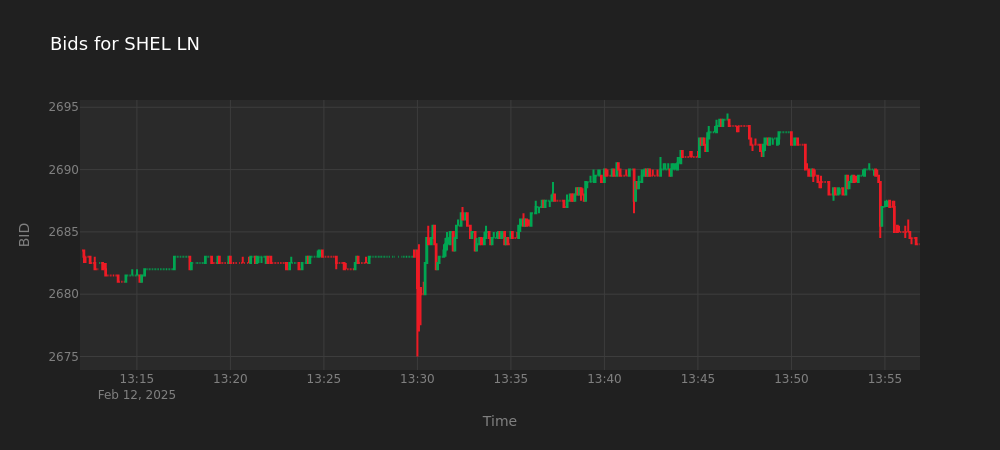

In [15]:
# Choose your Sym
ticker = "SHEL LN"

# Choose your chart render mode (Default is static "png", "jupyterlab" will make it interactive)
plot_render_mode = "png"

# Prepare your data
candlestick_data_shell_ln = dfOHLCPayload[dfOHLCPayload['instrumentID'] == ticker][['eventTimestamp', 'firstBidPrice', 'lastBidPrice', 'minBidPrice', 'maxBidPrice']]

# Create Candlestick Chart
fig = go.Figure(data=[go.Candlestick(
    x=candlestick_data_shell_ln['eventTimestamp'],
    open=candlestick_data_shell_ln['firstBidPrice'],
    high=candlestick_data_shell_ln['maxBidPrice'],
    low=candlestick_data_shell_ln['minBidPrice'],
    close=candlestick_data_shell_ln['lastBidPrice'],
    increasing_line_color='#00A652',
    decreasing_line_color='#ED1B25'
)])

fig.update_layout(
    title=f'Bids for {ticker}',
    xaxis_title='Time',
    yaxis_title='BID',
    xaxis_rangeslider_visible=False,
    plot_bgcolor='#2A2A2A',
    paper_bgcolor='#202020',
    font=dict(color='#808080'),
    title_font=dict(color='#FFFFFF', size=18),
    xaxis=dict(
        showgrid=True,
        gridcolor='#3D3D3D'
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='#3D3D3D'
    )
)

if plot_render_mode == "jupyterlab":
    fig.update_layout(autosize=True)
else:
    fig.update_layout(
        autosize=False,
        width=1000,
        height=450
    )

pio.renderers.default = plot_render_mode

fig.show()